In [1]:
import sys                                                                                                                                                                                                        
sys.path.insert(0, '/home/svu/e1498138/emri_search/work')                                                                                                                                                   
                                                                                                                                                                                                                    
from GWfuncs_noise import GravWaveAnalysis, build_waveform_response                                                                                                                                                 
from loglike_timemax_noise import LogLike                                                                                                                                                                           
import numpy as np                                                                                                                                                                                                        
import cupy as cp

In [2]:
use_gpu=True                                                                                                                                       
T = 12/12        # years                 
dt = 5       # seconds

# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 4.5
qS = np.pi
phiS = 0.
qK = 0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5                                                                                                                     
                                                                                                                                                                                                                                                                                                                                                    
                                        
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=use_gpu,tdi_gen=1)                                                                                                    
         

In [ ]:
params=[m1,m2,a,p0,e0,xI0,dist,qS,phiS,qK,phiK,Phi_phi0,Phi_theta0,Phi_r0]

In [4]:
# n-indexed mode selection parameters
n_vals = np.arange(-1,6)  # n from -1 to 5
ell = 2  # quadrupole only

In [5]:
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=True,tdi_gen=1)

In [6]:
# gwf_1yr = GravWaveAnalysis(T=1, dt=dt, use_gpu=True,tdi_gen=1)

In [7]:


loglike_obj= LogLike(                                                                                                                                                                                                       
    params=params,                                                                                                                                                                                                  
    waveform_response=waveform_response,                                                                                                                                                                            
    gwf=gwf,                                                                                                                                                                                                      
    add_noise=True,
    verbose=True,
    ell=ell,                                                                                                                                                                                                          
    n_vals=n_vals,
    M_mode=None,                                                                                                                                                                                                    
)  

[INFO] Added colored noise with seed=0
Delta_T for mode selection: 6311.629952709119 seconds
Selected modes (l,m,n): [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]]
Selected modes: [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]]
Flattened modes: [(2, 0, -1),

In [8]:
loglike_obj.signal

array([[ 2.29037824e-21, -5.96831485e-21,  1.52055623e-20, ...,
         8.94321381e-21, -5.56764019e-21,  3.35656256e-21],
       [ 1.27927097e-21, -1.87985533e-21,  1.62884555e-21, ...,
        -1.40448937e-20,  8.05921996e-21, -9.80704172e-21],
       [-1.10100941e-21,  1.19570151e-20, -1.61856432e-20, ...,
        -2.16018325e-21, -7.88098485e-21,  7.26155734e-21]])

In [9]:
%%time
#loglike at true param
logl_true=loglike_obj(params)
print(logl_true)

Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=7.316, rho=2.705
  Mode 1: <hf|hf>_timemax=45.86, rho=6.772
  Mode 2: <hf|hf>_timemax=196.8, rho=14.03
  Mode 3: <hf|hf>_timemax=187.7, rho=13.7
  Mode 4: <hf|hf>_timemax=93.88, rho=9.689
  Mode 5: <hf|hf>_timemax=32.98, rho=5.743
  Mode 6: <hf|hf>_timemax=9.393, rho=3.065
rho_m: [ 2.70474955  6.77214812 14.02851306 13.70036345  9.68896259  5.74259501
  3.06485009]
Dominant mode index: 2, rho: 14.03
beta=0.01186, rho_dom_M=14.03, rho_tot=25.34
X_scalar (time-maximized): 22.32
Time-maximized Log-likelihood: 20.7155
20.715541774376174
CPU times: user 405 ms, sys: 29.6 ms, total: 435 ms
Wall time: 518 ms


In [10]:
params_perturbed = list(params)                                                                                                                                                                                     
params_perturbed[0] *= 1.01                                                                                                                                                                                         
logl_perturbed = loglike_obj(params_perturbed)                                                                                                                                                                               
print(logl_perturbed)

Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=6.875, rho=2.622
  Mode 1: <hf|hf>_timemax=42.86, rho=6.547
  Mode 2: <hf|hf>_timemax=188, rho=13.71
  Mode 3: <hf|hf>_timemax=182.7, rho=13.52
  Mode 4: <hf|hf>_timemax=92.65, rho=9.626
  Mode 5: <hf|hf>_timemax=32.88, rho=5.734
  Mode 6: <hf|hf>_timemax=9.439, rho=3.072
rho_m: [ 2.62194231  6.54677249 13.71105146 13.51510149  9.6256335   5.73420621
  3.07223736]
Dominant mode index: 2, rho: 13.71
beta=0.01208, rho_dom_M=13.71, rho_tot=24.93
X_scalar (time-maximized): 5.097
Time-maximized Log-likelihood: 0.806527
0.8065267765823773


In [11]:

def logden_tm(params):
    logm1, logm2, a, p0, e0 = params
    return float(loglike_obj(np.array([10**logm1, 10**logm2, a, p0, e0,
                                    xI0, dist, qS, phiS, qK, phiK,
                                    Phi_phi0, Phi_theta0, Phi_r0])))

In [12]:
param_true = np.array([np.log10(m1), np.log10(m2), a, p0, e0])


In [13]:
# Sanity check at true params
print(logden_tm(param_true))

Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=7.316, rho=2.705
  Mode 1: <hf|hf>_timemax=45.86, rho=6.772
  Mode 2: <hf|hf>_timemax=196.8, rho=14.03
  Mode 3: <hf|hf>_timemax=187.7, rho=13.7
  Mode 4: <hf|hf>_timemax=93.88, rho=9.689
  Mode 5: <hf|hf>_timemax=32.98, rho=5.743
  Mode 6: <hf|hf>_timemax=9.393, rho=3.065
rho_m: [ 2.70474955  6.77214812 14.02851306 13.70036345  9.68896259  5.74259501
  3.06485009]
Dominant mode index: 2, rho: 14.03
beta=0.01186, rho_dom_M=14.03, rho_tot=25.34
X_scalar (time-maximized): 22.32
Time-maximized Log-likelihood: 20.7155
20.715541774376174


In [14]:
print('Initializing loglike_pure...')
params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

import loglike_pure_noise
loglike_p = loglike_pure_noise.LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    verbose=False,
    ell=ell, n_vals=n_vals, M_mode=None,
)

Initializing loglike_pure...


In [15]:
def logden_pure(params):
    logm1, logm2, a, p0, e0 = params
    return float(loglike_p(np.array([10**logm1, 10**logm2, a, p0, e0,
                                    xI0, dist, qS, phiS, qK, phiK,
                                    Phi_phi0, Phi_theta0, Phi_r0])))

In [16]:
# Sweep over qS
qS_range = np.sort(np.append(np.linspace(0, np.pi, 100), qS))

Sthree = np.zeros(len(qS_range))
Ssix = np.zeros(len(qS_range))
Snine = np.zeros(len(qS_range))
Stwelve = np.zeros(len(qS_range))

f_stats_pure = np.zeros(len(qS_range))

for i, qS_i in enumerate(qS_range):

    logm1, logm2, a_i, p0_i, e0_i = param_true
    h = gwf.xp.array(waveform_response(
        10**logm1, 10**logm2, a_i, p0_i, e0_i,
        xI0, dist, qS_i, phiS, qK, phiK,
        Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt,
    ))
    h_fft_r = gwf.freq_wave(h)
    rho_h   = float(gwf.xp.sqrt(gwf.inner(h_fft_r, h_fft_r)))
    Sthree[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h, N_seg=3))
    Ssix[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h, N_seg=6))
    Snine[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h, N_seg=9))
    Stwelve[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h, N_seg=12))
    # compute f
    f_stats_pure[i] = float(loglike_p(np.array([
        10**logm1, 10**logm2, a_i, p0_i, e0_i,
        xI0, dist, qS_i, phiS, qK, phiK,
        Phi_phi0, Phi_theta0, Phi_r0,
    ])))

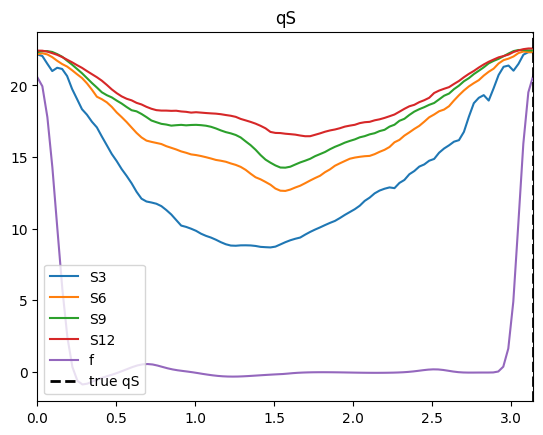

In [17]:
import matplotlib.pyplot as plt
param_range = np.linspace(0, np.pi, 101)
plt.plot(param_range, Sthree, label='S3')
plt.plot(param_range, Ssix, label='S6')
plt.plot(param_range, Snine, label='S9')
plt.plot(param_range, Stwelve, label='S12')
plt.plot(qS_range, f_stats_pure, label='f')
# add true 
plt.axvline(qS, color='k', linestyle='--', lw=2, label='true qS')
plt.xlim(0, np.pi)
plt.title('qS')
plt.legend(loc='lower left')
plt.show()

In [18]:
# sweep over phiS
phiS_range = np.sort(np.append(np.linspace(0, 2*np.pi, 100), phiS))
Sthree_phi = np.zeros(len(phiS_range))
Ssix_phi = np.zeros(len(phiS_range))
Snine_phi = np.zeros(len(phiS_range))
Stwelve_phi = np.zeros(len(phiS_range))
f_stats_pure_phi = np.zeros(len(phiS_range))
for i, phiS_i in enumerate(phiS_range):
    logm1, logm2, a_i, p0_i, e0_i = param_true
    h = gwf.xp.array(waveform_response(
        10**logm1, 10**logm2, a_i, p0_i, e0_i,
        xI0, dist, qS, phiS_i, qK, phiK,
        Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt,
    ))
    h_fft_r = gwf.freq_wave(h)
    rho_h   = float(gwf.xp.sqrt(gwf.inner(h_fft_r, h_fft_r)))
    Sthree_phi[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h, N_seg=3))
    Ssix_phi[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h, N_seg=6))
    Snine_phi[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h, N_seg=9))
    Stwelve_phi[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h, N_seg=12))
    # compute f 
    f_stats_pure_phi[i] = float(loglike_p(np.array([
        10**logm1, 10**logm2, a_i, p0_i, e0_i,
        xI0, dist, qS, phiS_i, qK, phiK,
        Phi_phi0, Phi_theta0, Phi_r0,
    ])))

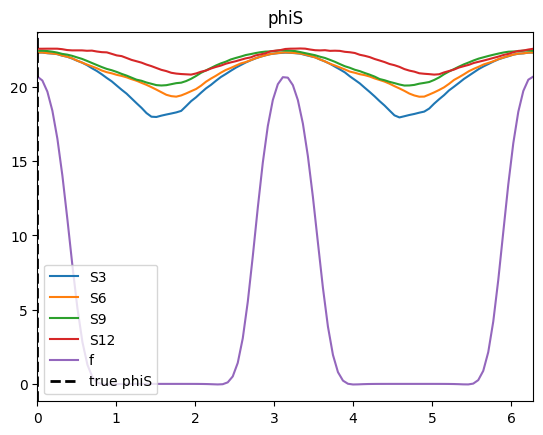

In [19]:
param_range = np.linspace(0, 2*np.pi, 101)
plt.plot(param_range, Sthree_phi, label='S3')
plt.plot(param_range, Ssix_phi, label='S6')
plt.plot(param_range, Snine_phi, label='S9')
plt.plot(param_range, Stwelve_phi, label='S12')
plt.plot(phiS_range, f_stats_pure_phi, label='f')
# add true 
plt.axvline(phiS, color='k', linestyle='--', lw = 2, label='true phiS')
plt.xlim(0, 2*np.pi)
plt.title('phiS')
plt.legend(loc='lower left')
plt.show()

In [20]:
f_stats_pure

array([ 2.05622340e+01,  1.99367665e+01,  1.77835708e+01,  1.42729751e+01,
        9.97365367e+00,  5.74818763e+00,  2.41275974e+00,  3.43184608e-01,
       -6.12319242e-01, -8.71096320e-01, -8.12050961e-01, -6.64160031e-01,
       -5.17416156e-01, -3.93413001e-01, -2.84720970e-01, -1.76521085e-01,
       -5.77397191e-02,  7.36546604e-02,  2.12943353e-01,  3.47724943e-01,
        4.60294253e-01,  5.33227164e-01,  5.56315482e-01,  5.24843207e-01,
        4.48142430e-01,  3.51450475e-01,  2.57197021e-01,  1.79248104e-01,
        1.19636263e-01,  7.29194049e-02,  2.84656797e-02, -2.01940295e-02,
       -7.45475037e-02, -1.32588347e-01, -1.85372842e-01, -2.33130561e-01,
       -2.72308614e-01, -3.00079789e-01, -3.16185914e-01, -3.21663048e-01,
       -3.16936318e-01, -3.03710629e-01, -2.85458248e-01, -2.63883172e-01,
       -2.41374996e-01, -2.18608859e-01, -1.97407011e-01, -1.76900726e-01,
       -1.58150720e-01, -1.40639934e-01, -1.12038759e-01, -7.98116155e-02,
       -5.59566410e-02, -

In [21]:
f_stats_pure_phi

array([ 2.07020072e+01,  2.07020072e+01,  2.04341781e+01,  1.96850253e+01,
        1.83991723e+01,  1.65124620e+01,  1.40249125e+01,  1.10743678e+01,
        7.96279884e+00,  5.09101363e+00,  2.81162422e+00,  1.28594840e+00,
        4.46258700e-01,  8.23974469e-02, -2.81569254e-02, -3.89899008e-02,
       -2.54887658e-02, -1.31154910e-02, -6.01707659e-03, -2.63333450e-03,
       -1.15650974e-03, -5.32146949e-04, -2.66421152e-04, -1.49934699e-04,
       -9.74094716e-05, -7.45229906e-05, -6.79705218e-05, -7.42247654e-05,
       -9.66619127e-05, -1.48324257e-04, -2.62959766e-04, -5.24526033e-04,
       -1.13942936e-03, -2.59488828e-03, -5.93009449e-03, -1.29087614e-02,
       -2.49250241e-02, -3.71760915e-02, -2.19629431e-02,  1.02149171e-01,
        5.01072786e-01,  1.41499225e+00,  3.06833010e+00,  5.52501785e+00,
        8.59274499e+00,  1.18682830e+01,  1.49019634e+01,  1.73645272e+01,
        1.91184861e+01,  2.01848532e+01,  2.06583361e+01,  2.06266294e+01,
        2.01223200e+01,  

In [33]:
phiS

0.0

In [37]:
Stwelve_phi

array([22.57344849, 22.57344849, 22.57770535, 22.57774625, 22.57724172,
       22.54423623, 22.48522448, 22.46320738, 22.46388535, 22.46337355,
       22.43699086, 22.4476042 , 22.38692819, 22.34380361, 22.32972212,
       22.22898384, 22.12549381, 22.07660446, 21.95040619, 21.82197075,
       21.73058275, 21.63784646, 21.50835916, 21.40255938, 21.27681868,
       21.15283963, 21.06842169, 20.95494517, 20.90088215, 20.87015917,
       20.85076902, 20.83214265, 20.90930914, 21.0245905 , 21.10504833,
       21.2401933 , 21.3492319 , 21.43997022, 21.56514369, 21.65448027,
       21.73308561, 21.82944231, 21.92477237, 21.98948825, 22.12304055,
       22.19426524, 22.26884028, 22.3994748 , 22.44522292, 22.48373421,
       22.55798073, 22.57723306, 22.58091376, 22.591512  , 22.57937539,
       22.5203064 , 22.47420767, 22.46108609, 22.47562886, 22.43200582,
       22.4420335 , 22.42961604, 22.36685914, 22.3376057 , 22.28717382,
       22.1681093 , 22.0985532 , 22.01043583, 21.88372027, 21.78

In [40]:
# sweep for logm2
logm2_range = np.linspace(0.99, 1.01, 101)
Sthree_logm2 = np.zeros(len(logm2_range))
Ssix_logm2 = np.zeros(len(logm2_range))
Snine_logm2 = np.zeros(len(logm2_range))
Stwelve_logm2 = np.zeros(len(logm2_range))

for i, logm2_i in enumerate(logm2_range):
    logm1, a_i, p0_i, e0_i = param_true[0], param_true[2], param_true[3], param_true[4]
    try:
        h = gwf.xp.array(waveform_response(
            10**logm1, 10**logm2_i, a_i, p0_i, e0_i,
            xI0, dist, qS, phiS, qK, phiK,
            Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt,
        ))
        h_fft_r = gwf.freq_wave(h)
        rho_h   = float(gwf.xp.sqrt(gwf.inner(h_fft_r, h_fft_r)))
        Sthree_logm2[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h, N_seg=3))
        Ssix_logm2[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h, N_seg=6))
        Snine_logm2[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h, N_seg=9))
        Stwelve_logm2[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h, N_seg=12))
    except AssertionError as e:
        print(f"Error for logm2={logm2_i}: {e}")
        Sthree_logm2[i] = np.nan
        Ssix_logm2[i] = np.nan
        Snine_logm2[i] = np.nan
        Stwelve_logm2[i] = np.nan

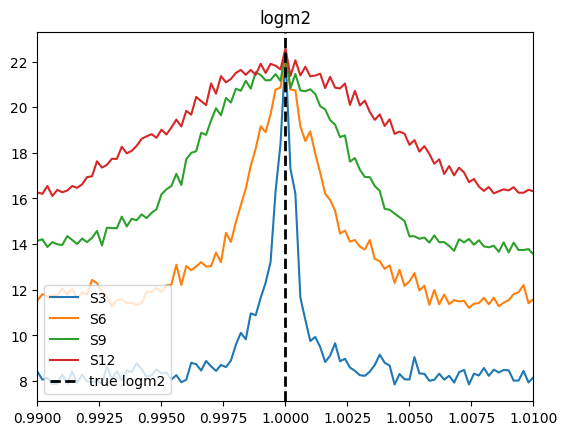

In [42]:
param_range = np.linspace(0.99, 1.01, 101)
plt.plot(param_range, Sthree_logm2, label='S3')
plt.plot(param_range, Ssix_logm2, label='S6')
plt.plot(param_range, Snine_logm2, label='S9')
plt.plot(param_range, Stwelve_logm2, label='S12')

# add true 
plt.axvline(logm2, color='k', linestyle='--', lw = 2,label='true logm2')
plt.xlim(0.99, 1.01)
plt.title('logm2')
plt.legend(loc='lower left')
plt.show()

In [43]:
# sweep for logm1
logm1_range = np.linspace(5.99, 6.01, 101)
Sthree_logm1 = np.zeros(len(logm1_range))
Ssix_logm1 = np.zeros(len(logm1_range))
Snine_logm1 = np.zeros(len(logm1_range))
Stwelve_logm1 = np.zeros(len(logm1_range))

for i, logm1_i in enumerate(logm1_range):
    logm2, a_i, p0_i, e0_i = param_true[1], param_true[2], param_true[3], param_true[4]
    try:
        h = gwf.xp.array(waveform_response(
            10**logm1_i, 10**logm2, a_i, p0_i, e0_i,
            xI0, dist, qS, phiS, qK, phiK,
            Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt,
        ))
        h_fft_r = gwf.freq_wave(h)
        rho_h   = float(gwf.xp.sqrt(gwf.inner(h_fft_r, h_fft_r)))
        Sthree_logm1[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h, N_seg=3))
        Ssix_logm1[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h, N_seg=6))
        Snine_logm1[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h, N_seg=9))
        Stwelve_logm1[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h, N_seg=12))
    except AssertionError as e:
        print(f"Error for logm1={logm1_i}: {e}")
        Sthree_logm1[i] = np.nan
        Ssix_logm1[i] = np.nan
        Snine_logm1[i] = np.nan
        Stwelve_logm1[i] = np.nan

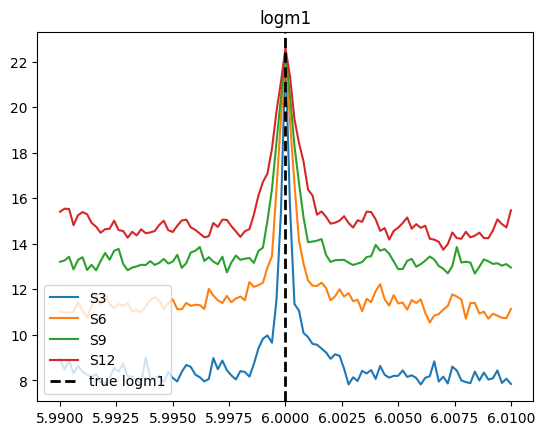

In [45]:
plt.plot(logm1_range, Sthree_logm1, label='S3')
plt.plot(logm1_range, Ssix_logm1, label='S6')
plt.plot(logm1_range, Snine_logm1, label='S9')
plt.plot(logm1_range, Stwelve_logm1, label='S12')

plt.axvline(logm1, color='k', linestyle='--', lw = 2,label='true logm1')
plt.title('logm1')
plt.legend(loc='lower left')   
plt.show()